In [2]:
import os
import glob
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
#check images size
import os
from collections import Counter
from PIL import Image

IMAGE_DIR = "MESSIDOR/images"


def count_image_sizes(image_dir):
    size_counter = Counter()
    failed_images = []

    for root, _, files in os.walk(image_dir):
        for fname in files:
            path = os.path.join(root, fname)
            try:
                with Image.open(path) as img:
                    size_counter[img.size] += 1  # (width, height)
            except Exception as e:
                failed_images.append(path)

    return size_counter, failed_images


if __name__ == "__main__":
    size_counter, failed_images = count_image_sizes(IMAGE_DIR)

    print("Image size distribution:\n")
    for (w, h), count in sorted(size_counter.items()):
        print(f"{w} x {h} : {count} images")
    MAX_SIZE = w

    if failed_images:
        print("\nFailed to read the following files:")
        for f in failed_images:
            print(f)


Image size distribution:

898 x 898 : 23 images
900 x 900 : 327 images
902 x 902 : 80 images
904 x 904 : 81 images
906 x 906 : 15 images
908 x 908 : 1 images
1370 x 1370 : 2 images
1372 x 1372 : 62 images
1374 x 1374 : 178 images
1376 x 1376 : 114 images
1378 x 1378 : 94 images
1380 x 1380 : 104 images
1382 x 1382 : 42 images
1384 x 1384 : 13 images
1386 x 1386 : 5 images
1388 x 1388 : 1 images
1440 x 1440 : 7 images
1442 x 1442 : 31 images
1444 x 1444 : 193 images
1446 x 1446 : 277 images
1448 x 1448 : 74 images
1450 x 1450 : 19 images
1452 x 1452 : 2 images


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def show_padded_image(img_padded, title="Padded Image"):
    """
    Displays a padded NumPy image array (grayscale or RGB).
    """

    plt.figure(figsize=(5, 5))

    if img_padded.ndim == 2:  # Grayscale
        plt.imshow(img_padded, cmap="gray")
    else:  # RGB / multi-channel
        plt.imshow(img_padded)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [4]:
# Configuration
IMAGE_DIR = 'MESSIDOR/images/'
TARGET_SIZE = (128, 128)

def preprocess_image(image_path, size=TARGET_SIZE):
    """
    Loads an image, resizes it, and flattens it.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Resize
    img_resized = cv2.resize(img, size)
    
    # Flatten
    # Image is (128, 128, 3) -> flattened vector of size 128*128*3
    img_flat = img_resized.flatten()
    
    return img_flat

def preproprocess_image_noresize(image_path, max_size=MAX_SIZE):
    """
    Loads a square image, pads it with black pixels equally on all sides
    to reach (max_size, max_size), then flattens and returns it.
    """

    img = Image.open(image_path)
    img_np = np.array(img)
    # show_padded_image(img_np,title="Unpadded Image")

    h, w = img_np.shape[:2]
    assert h == w, f"Image is not square: {h}x{w}"
    assert h <= max_size, f"Image size {h} exceeds max_size {max_size}"

    pad_total = max_size - h
    pad_before = pad_total // 2
    pad_after = pad_total - pad_before

    if img_np.ndim == 2:  # Grayscale
        padding = (
            (pad_before, pad_after),
            (pad_before, pad_after),
        )
    else:  # RGB / multi-channel
        padding = (
            (pad_before, pad_after),
            (pad_before, pad_after),
            (0, 0),
        )

    img_padded = np.pad(
        img_np,
        padding,
        mode="constant",
        constant_values=0
    )
    # show_padded_image(img_padded,title="Padded Image")
    img_flat = img_padded.flatten()
    return img_flat

In [5]:
preproprocess_image_noresize("MESSIDOR/images/20051020_57157_0100_PP.png")

array([0, 0, 0, ..., 0, 0, 0], shape=(6324912,), dtype=uint8)

In [5]:
# Load all images
image_files = glob.glob(os.path.join(IMAGE_DIR, '*.png')) + \
              glob.glob(os.path.join(IMAGE_DIR, '*.jpg')) + \
              glob.glob(os.path.join(IMAGE_DIR, '*.JPG'))
image_files.sort()

print(f"Found {len(image_files)} images.")

data_vectors = []
valid_files = []

for f in tqdm(image_files):
    vec = preprocess_image(f)
    if vec is not None:
        data_vectors.append(vec)
        valid_files.append(f)

# Construct Data Matrix H
# Rows = flattened features, Columns = images
H = np.column_stack(data_vectors)

print(f"Data Matrix H shape: {H.shape}")

Found 1745 images.


  0%|          | 0/1745 [00:00<?, ?it/s]

100%|██████████| 1745/1745 [00:41<00:00, 42.50it/s] 


Data Matrix H shape: (49152, 1745)


In [13]:
# Calculate Gramians on GPU using PyTorch
# G1 = H * H^T (Size: Features x Features)
# G2 = H^T * H (Size: Samples x Samples)

def gpu_batched_matmul(H):
    try:
        del H_batch_1_gpu,H_batch_2_gpu
    except:
        pass
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Convert H to PyTorch tensor and move to GPU
    # H_tensor = torch.from_numpy(H).float().to(device)

    print("Calculating H^T H (Gramian 2) on GPU...")
    no_batches = 4
    col_size = H.shape[1]
    batch_size = col_size//no_batches
    tensor_tup = np.array_split(H,no_batches,1)
    total_HTH_lst = []
    for H_batch_1 in tqdm(tensor_tup):
        cols = []
        for H_batch_2 in tensor_tup:
            H_batch_1_gpu = torch.from_numpy(H_batch_1).float().to(device)
            H_batch_2_gpu = torch.from_numpy(H_batch_2).float().to(device)
            HTH_tensor_batch = torch.matmul(H_batch_1_gpu.T, H_batch_2_gpu).cpu().numpy()
            del H_batch_1_gpu,H_batch_2_gpu
            cols.append(HTH_tensor_batch)
        HTH_row = np.concatenate(cols,axis=1)
        total_HTH_lst.append(HTH_row)
    HTH_tensor = np.concatenate(total_HTH_lst,axis = 0)
    HTH = HTH_tensor
    print(f"H^T H shape: {HTH.shape}")
    return HTH

H_raw = H
H_cov = H_raw-H_raw.mean(axis=1,keepdims=True)
H_cor = (H_raw-H_raw.mean(axis=1,keepdims=True))/H_raw.std(axis=1,keepdims=True)







: 

In [9]:
import numpy as np
from numpy import linalg as LA

eigenvalues = LA.eigvalsh(HTH)

print(eigenvalues)

[-6.7119245e+08 -3.8183558e+08 -2.2842502e+08 ...  9.7206318e+11
  7.1147108e+12  5.9231332e+13]


--- Eigenvalue Analysis  ---
Total Eigenvalues: 1745
Beta (acceptable variance loss): 0.01
Variance cutoff (1 - beta): 99.00%
Components to keep: 10
Actual Variance Explained: 99.04%
----------------------------------------


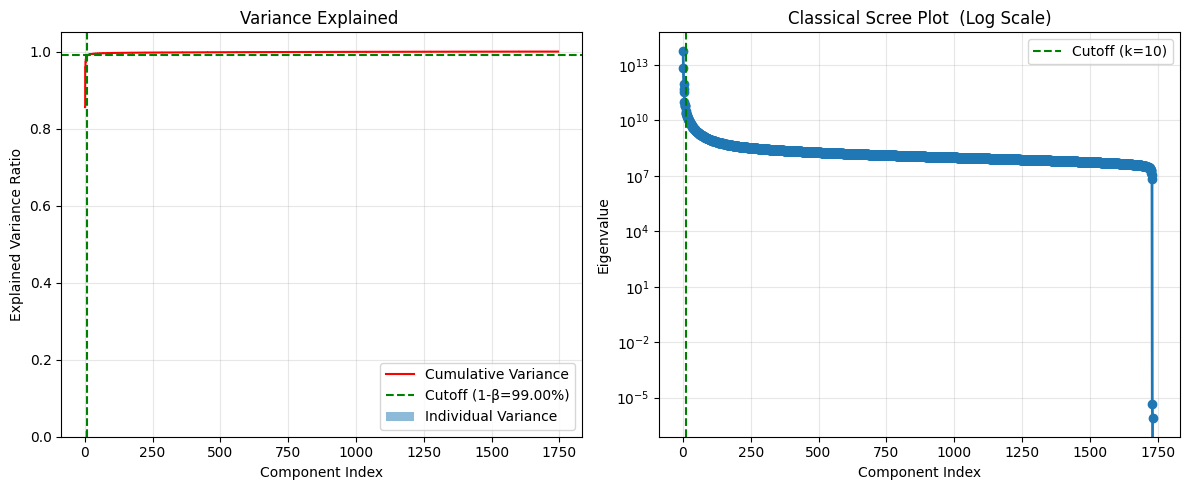

(np.int64(10),
 array([5.9231332e+13, 7.1147108e+12, 9.7206318e+11, 5.3210563e+11,
        3.6101597e+11, 1.0119825e+11, 7.1313531e+10, 6.3018959e+10,
        5.8132259e+10, 3.3676866e+10], dtype=float32),
 np.float32(0.99040854))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_precomputed_eigenvalues(eigenvalues, beta=0.01, title_suffix=""):
    """
    Performs scree analysis on precomputed eigenvalues.

    Parameters:
    - eigenvalues: 1D array of eigenvalues (need not be sorted)
    - beta: acceptable variance loss (0 to 1).
            Keeps components capturing at least (1 - beta) variance.
    - title_suffix: optional string for plot titles
    """
    
    variance_cutoff = 1 - beta
    
    # 1. Sort eigenvalues (descending)
    eigenvalues = np.array(eigenvalues)
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Remove tiny negative values due to numerical noise
    eigenvalues[eigenvalues < 0] = 0
    
    # 2. Variance metrics
    total_variance = np.sum(eigenvalues)
    
    if total_variance == 0:
        raise ValueError("Total variance is zero. Check eigenvalues.")
    
    explained_variance_ratio = eigenvalues / total_variance
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    # 3. Select k
    k_components = np.searchsorted(cumulative_variance, variance_cutoff) + 1
    
    print(f"--- Eigenvalue Analysis {title_suffix} ---")
    print(f"Total Eigenvalues: {len(eigenvalues)}")
    print(f"Beta (acceptable variance loss): {beta}")
    print(f"Variance cutoff (1 - beta): {variance_cutoff:.2%}")
    print(f"Components to keep: {k_components}")
    print(f"Actual Variance Explained: {cumulative_variance[k_components-1]:.2%}")
    print("-" * 40)

    # 4. Plot
    components = np.arange(1, len(eigenvalues) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Variance explained
    plt.subplot(1, 2, 1)
    plt.bar(components, explained_variance_ratio, alpha=0.5, label='Individual Variance')
    plt.step(components, cumulative_variance, where='mid',
             label='Cumulative Variance', color='red')
    plt.axhline(y=variance_cutoff, color='green', linestyle='--',
                label=f'Cutoff (1-β={variance_cutoff:.2%})')
    plt.axvline(x=k_components, color='green', linestyle='--')
    plt.title(f'Variance Explained {title_suffix}')
    plt.xlabel('Component Index')
    plt.ylabel('Explained Variance Ratio')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    # Plot 2: Classical Scree
    plt.subplot(1, 2, 2)
    plt.plot(components, eigenvalues, 'o-', linewidth=2)
    plt.axvline(x=k_components, color='green', linestyle='--',
                label=f'Cutoff (k={k_components})')
    plt.yscale('log')
    plt.title(f'Classical Scree Plot {title_suffix} (Log Scale)')
    plt.xlabel('Component Index')
    plt.ylabel('Eigenvalue')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return k_components, eigenvalues[:k_components], cumulative_variance[k_components-1]

analyze_precomputed_eigenvalues(eigenvalues,beta=0.01)

In [ ]:
print("Calculating H H^T (Gramian 1) on GPU...")
try:
    del H_batch_1_gpu,H_batch_2_gpu
except:
    pass
no_batches = 100
# try:
tensor_tup = np.array_split(H,no_batches,axis=0)
total_HHT_lst = []
for H_batch_1 in tensor_tup:
    cols = []
    for H_batch_2 in tensor_tup:
        H_batch_1_gpu = torch.from_numpy(H_batch_1).float().to(device)
        H_batch_2_gpu = torch.from_numpy(H_batch_2).float().to(device)
        HHT_tensor_batch = torch.matmul(H_batch_1_gpu, H_batch_2_gpu.T).cpu().numpy()
        cols.append(HHT_tensor_batch)
        print(len(cols))
        del H_batch_1_gpu, H_batch_2_gpu
    HHT_row = np.concatenate(cols,axis=1)
    total_HHT_lst.append(HTH_row)
HHT_tensor = np.concatenate(total_HHT_lst,axis = 0)
HHT = HHT_tensor
print(f"H H^T shape: {HHT.shape}")
# except RuntimeError as e:
#     print(f"GPU Error (likely OOM): {e}")
#     print("H H^T is too large for GPU memory.")
# except MemoryError:
#     print("H H^T is too large for CPU memory (when moving back).")

# Clean up GPU memory
if 'HTH_tensor' in locals(): del HTH_tensor
if 'HHT_tensor' in locals(): del HHT_tensor
torch.cuda.empty_cache()

Calculating H H^T (Gramian 1) on GPU...


KeyboardInterrupt: 


Running Covariance Analysis (Centered)...
--- Analysis: (Correlation) ---
Total Eigenvalues: 1745
Beta (acceptable variance loss): 0.01
Variance cutoff (1 - beta): 99.00%
Components to keep: 1458
Actual Variance Explained: 99.00%
----------------------------------------


(np.int64(1458),
 array([3.70078761e+07, 1.10217421e+07, 5.69433255e+06, ...,
        3.77255190e+03, 3.76838627e+03, 3.75653776e+03], shape=(1458,)),
 np.float64(0.9900403178710361))

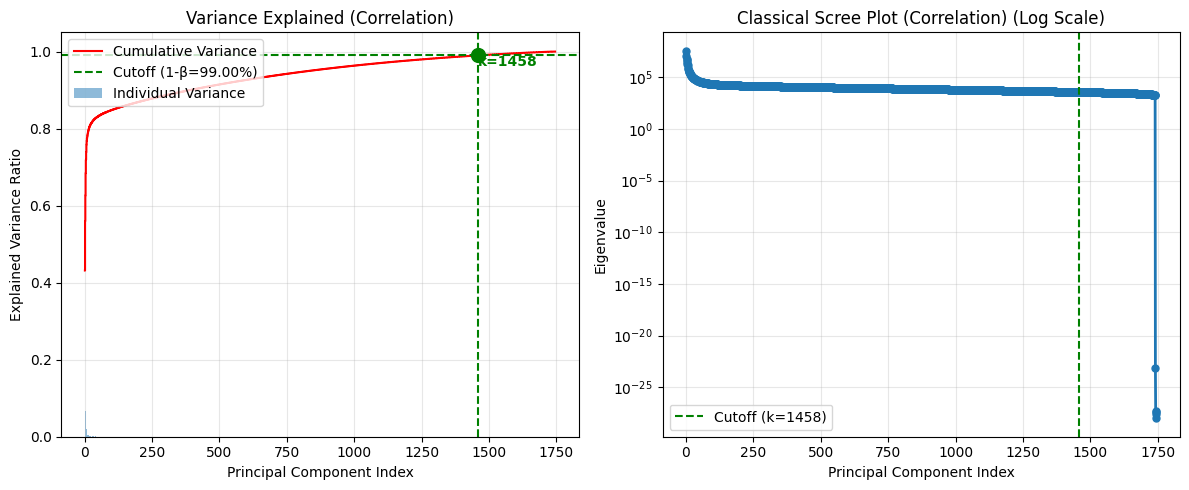

In [8]:
def analyze_eigenvalues(H, beta=0.01, analysis_type='raw'):
    """
    Performs eigenvalue analysis (Scree Plot) on matrix H.
    
    Parameters:
    - H: The data matrix (rows=features, cols=samples)
    - beta: Small threshold for acceptable variance loss (0.0 to 1.0).
            The cutoff is set at (1 - beta) variance explained.
            e.g., beta=0.01 means keep components capturing at least 99% of variance.
            e.g., beta=0.05 means keep components capturing at least 95% of variance.
    - analysis_type: 'raw', 'covariance', or 'correlation'
    """
    variance_cutoff = 1 - beta
    
    # 1. PREPROCESSING based on Analysis Type
    if analysis_type == 'raw':
        # Second Moment Analysis (No centering)
        H_processed = H
        title_suffix = "(Raw Second Moment)"
    elif analysis_type == 'covariance':
        # Covariance Analysis (Center the data)
        H_processed = (H - np.mean(H, axis=1)[:,None])
        title_suffix = "(Covariance)"
    elif analysis_type == 'correlation':
        # Correlation Analysis (Center + Scale by Std Dev)
        H_processed = (H - np.mean(H, axis=1)[:,None]) / np.std(H, axis=1)[:,None]
        title_suffix = "(Correlation)"
    else:
        raise ValueError("Invalid analysis_type. Choose 'raw', 'covariance', or 'correlation'.")

    # 2. COMPUTE EIGENVALUES
    # We use SVD: H = U S V.T
    # Eigenvalues of H^T H are equal to (Singular Values)^2
    U, S, Vt = np.linalg.svd(H_processed, full_matrices=False)
    eigenvalues = S ** 2
    
    # 3. CALCULATE VARIANCE METRICS
    total_variance = np.sum(eigenvalues)
    explained_variance_ratio = eigenvalues / total_variance
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    # 4. SELECT EIGENVALUES BASED ON BETA
    # Find the number of components to capture at least (1 - beta) variance
    k_components = np.searchsorted(cumulative_variance, variance_cutoff) + 1
    
    print(f"--- Analysis: {title_suffix} ---")
    print(f"Total Eigenvalues: {len(eigenvalues)}")
    print(f"Beta (acceptable variance loss): {beta}")
    print(f"Variance cutoff (1 - beta): {variance_cutoff:.2%}")
    print(f"Components to keep: {k_components}")
    print(f"Actual Variance Explained: {cumulative_variance[k_components-1]:.2%}")
    print("-" * 40)

    # 5. GENERATE PLOTS
    components = np.arange(1, len(eigenvalues) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Variance Explained (Bar + Cumulative)
    plt.subplot(1, 2, 1)
    plt.bar(components, explained_variance_ratio, alpha=0.5, label='Individual Variance')
    plt.step(components, cumulative_variance, where='mid', label='Cumulative Variance', color='red')
    plt.axhline(y=variance_cutoff, color='green', linestyle='--', label=f'Cutoff (1-β={variance_cutoff:.2%})')
    plt.axvline(x=k_components, color='green', linestyle='--')
    plt.plot(k_components, cumulative_variance[k_components-1], 'go', markersize=10)
    plt.text(k_components + 1, cumulative_variance[k_components-1], 
             f'k={k_components}', color='green', fontweight='bold', va='top')
    plt.title(f'Variance Explained {title_suffix}')
    plt.xlabel('Principal Component Index')
    plt.ylabel('Explained Variance Ratio')
    # plt.xlim(0, 40)
    # plt.ylim(0.9, 1.1)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)

    # Plot 2: Classical Scree Plot (Eigenvalues)
    plt.subplot(1, 2, 2)
    plt.plot(components, eigenvalues, 'o-', linewidth=2, markersize=5)
    plt.axvline(x=k_components, color='green', linestyle='--', label=f'Cutoff (k={k_components})')
    plt.title(f'Classical Scree Plot {title_suffix} (Log Scale)')
    plt.xlabel('Principal Component Index')
    plt.yscale('log')
    # plt.xlim(0, 40)
    plt.ylabel('Eigenvalue')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"resized_{analysis_type}")
    
    return k_components, eigenvalues[:k_components], cumulative_variance[k_components-1]

# Run ALL analyses)

print("\nRunning Covariance Analysis (Centered)...")
analyze_eigenvalues(H, beta=0.01, analysis_type='correlation')